#### Task 0: Course project dataset exploration
##### a) Dataset choice
Dataset name: Financials Dataset  
Source: Kaggle  
Link: https://www.kaggle.com/datasets/atharvaarya25/financials

##### b) Dataset description
The dataset contains financial information for multiple companies across several years and is suitable for financial analysis and exploratory data analysis. It includes key financial variables such as revenue, profit, and other indicators.

Each row represents a company’s financial performance in a given year.
The dataset includes both numerical and categorical variables, allowing for analysis of company performance across time and between firms.

The dataset contains 700 rows and 16 columns (the code is below).

##### Project idea

In this project, I plan to analyze financial performance across companies, explore the relationship between revenue and profit, examine trends over time, and compare performance across companies.

In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 700
Columns: 16


In [2]:
# c)
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("data/Financials.csv")
display(df.head())

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (700, 16)

Columns:
Index(['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number',
       ' Month Name ', 'Year'],
      dtype='object')

Data types:
Segment                  object
Country                  object
 Product                 object
 Discount Band           object
 Units Sold              object
 Manufacturing Price     object
 Sale Price              object
 Gross Sales             object
 Discounts               object
  Sales                  object
 COGS                    object
 Profit                  object
Date                     object
Month Number              int64
 Month Name              object
Year                      int64
dtype: object


In [13]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')


In [4]:
display(df.describe())

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


In [5]:
display(df.isna().sum())

Segment                  0
Country                  0
 Product                 0
 Discount Band           0
 Units Sold              0
 Manufacturing Price     0
 Sale Price              0
 Gross Sales             0
 Discounts               0
  Sales                  0
 COGS                    0
 Profit                  0
Date                     0
Month Number             0
 Month Name              0
Year                     0
dtype: int64

In [26]:
# Visualization 1: Sales by product across countries
df.columns = df.columns.str.strip()
df["Sales"] = df["Sales"].replace('[\$,]', '', regex=True).astype(float) #clean the data

sales_by_country_product = df.groupby(["Country", "Product"])["Sales"].sum().reset_index() #group the data

pivot_table = sales_by_country_product.pivot(index="Country", columns="Product", values="Sales") #pivot the data

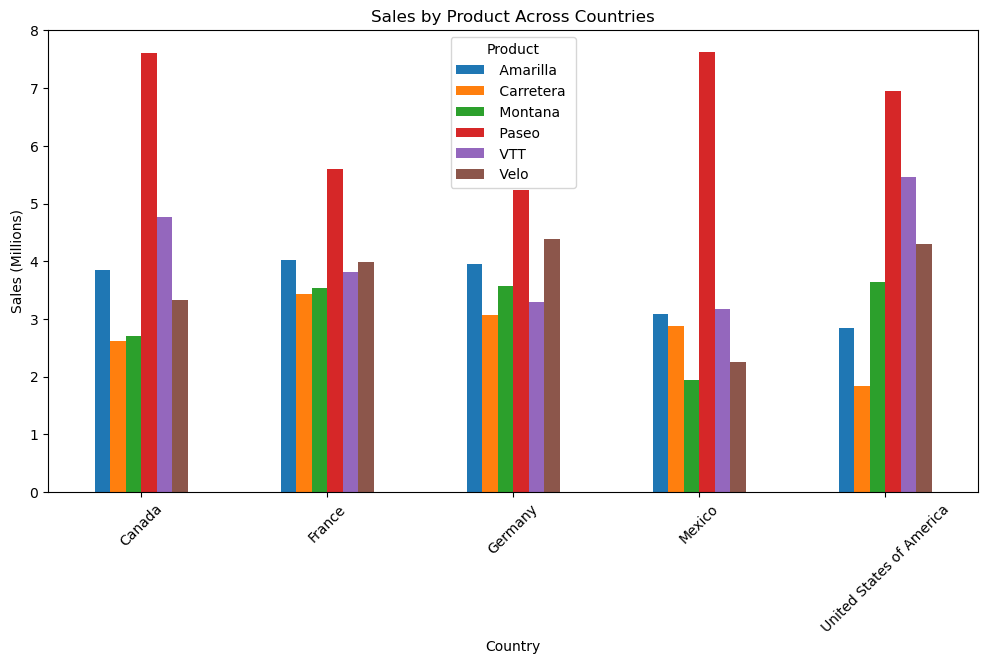

In [30]:
# Grouped bar chart
import matplotlib.pyplot as plt

pivot_table_millions = pivot_table / 1_000_000

pivot_table_millions.plot(kind="bar", figsize=(12,6))

plt.title("Sales by Product Across Countries")
plt.xlabel("Country")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)

plt.show()

In [38]:
# Visualization 2: Sales, COGS, Profit by product
df.columns = df.columns.str.strip()

cols = ["Sales", "COGS", "Profit"]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

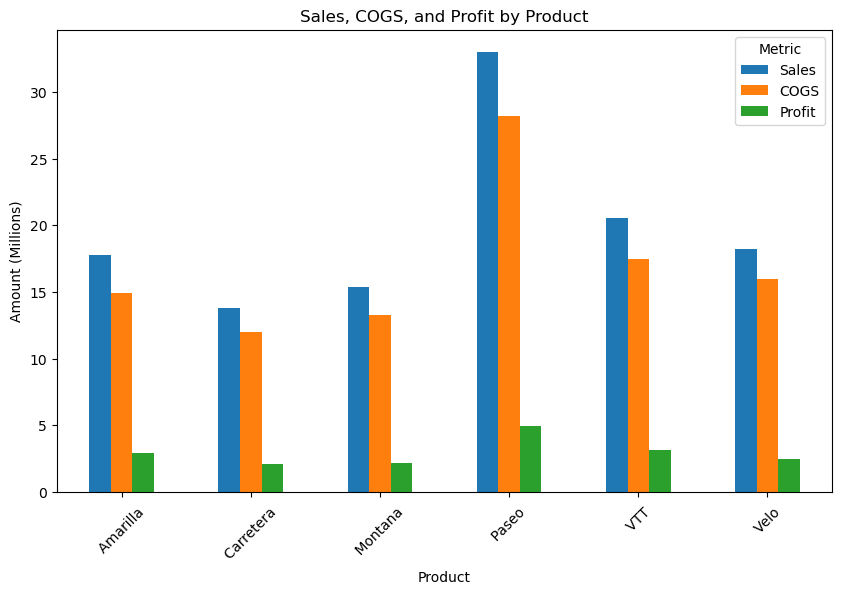

In [39]:
# Grouped bar chart
product_summary = df.groupby("Product")[["Sales", "COGS", "Profit"]].sum()

product_summary_millions = product_summary / 1_000_000

product_summary_millions.plot(kind="bar", figsize=(10, 6))

plt.title("Sales, COGS, and Profit by Product")
plt.xlabel("Product")
plt.ylabel("Amount (Millions)")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.show()

#### Task 1: Setting up an API key and .env file

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

print(api_key[:5] + "...")

4533a...
